In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

def main():
    path = r'car1.jpg'
    
    # Load YOLO model (for cars)
    model = YOLO("yolov8n.pt")
    model.to("cpu")

    image = cv2.imread(path)

    if image is None:
        print("Error: Could not load image")
        return

    # Car detection 
    results = model(image, device="cpu")

    car_count = 0

    for result in results:
        boxes = result.boxes
        for box in boxes:
            cls = int(box.cls[0])
            label = model.names[cls]

            if label == "car":
                car_count += 1
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image,
                            f"Car {car_count}",
                            (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7,
                            (0, 255, 0),
                            2)


    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title("Car Detection with YOLOv8 - Total Cars: {}".format(car_count))
    plt.axis("off")
    plt.show()


0: 448x640 5 persons, 1 car, 117.2ms
Speed: 4.2ms preprocess, 117.2ms inference, 910.5ms postprocess per image at shape (1, 3, 448, 640)


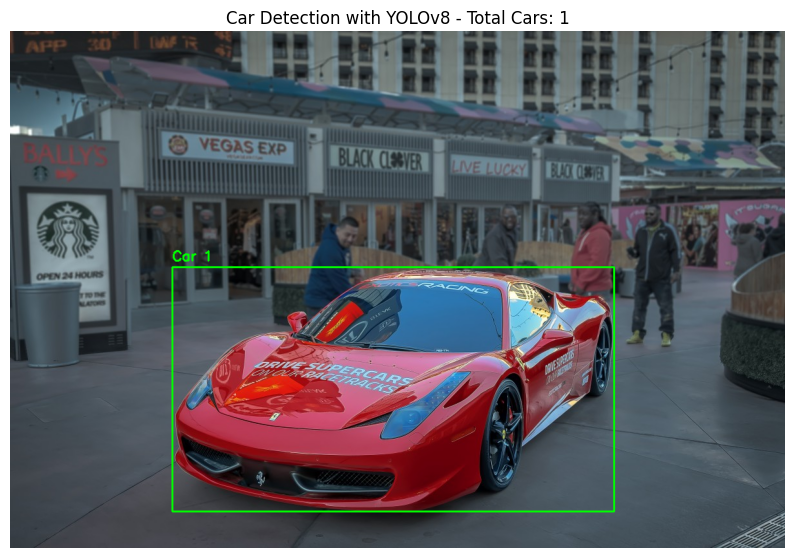

In [ ]:
if __name__ == "__main__":
    main()